<a href="https://colab.research.google.com/github/Aryan-theccool/ML/blob/main/placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [4]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

rows = 10000

data = []

branches = ['CSE','IT','ECE','ME','CE','EE']
tiers = [1,2,3]

for i in range(rows):
    cgpa = round(np.random.uniform(5.0, 10.0),2)
    communication = random.randint(1,10)
    aptitude = random.randint(30,100)
    projects = random.randint(0,6)
    internships = random.randint(0,3)
    attendance = random.randint(55,100)
    coding = random.randint(20,100)
    certifications = random.randint(0,8)
    backlogs = random.randint(0,5)
    tier = random.choice(tiers)
    branch = random.choice(branches)

    score = (
        cgpa*10 +
        communication*4 +
        aptitude*0.4 +
        projects*5 +
        internships*8 +
        attendance*0.2 +
        coding*0.3 +
        certifications*3 -
        backlogs*10 -
        tier*5
    )

    placed = 1 if score > 120 else 0

    data.append([
        cgpa, communication, aptitude, projects,
        internships, attendance, coding,
        certifications, backlogs, tier, branch, placed
    ])

df = pd.DataFrame(data, columns=[
    'CGPA','Communication','Aptitude','Projects',
    'Internships','Attendance','Coding',
    'Certifications','Backlogs','College_Tier',
    'Branch','Placed'
])

df.to_csv("students_large.csv", index=False)
df.head()

,CGPA,Communication,Aptitude,Projects,Internships,Attendance,Coding,Certifications,Backlogs,College_Tier,Branch,Placed
0,6.87,6,41,2,1,65,67,3,0,2,CE,1
1,9.75,3,50,3,1,72,42,4,4,1,EE,1
2,8.66,9,86,0,3,94,45,4,4,1,ECE,1
3,7.99,2,49,3,0,96,97,2,2,3,ECE,1
4,5.78,7,53,3,1,93,22,1,1,1,ECE,1


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

df = pd.read_csv("students_large.csv")

le = LabelEncoder()
df['Branch'] = le.fit_transform(df['Branch'])

X = df.drop("Placed", axis=1)
y = df["Placed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

Accuracy: 0.996


In [6]:
joblib.dump(model, "placement_model.pkl")
print("Model Saved")

Model Saved


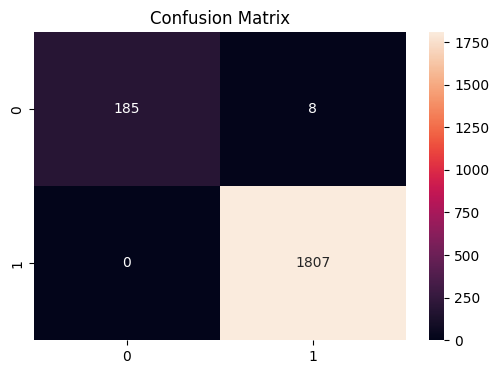

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [8]:
from google.colab import files

files.download("students_large.csv")
files.download("placement_model.pkl")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load model
model = joblib.load("placement_model.pkl")

st.set_page_config(page_title="Placement Predictor", layout="centered")

st.title("🎓 Student Placement Prediction System")
st.write("Enter student details to predict placement chances.")

cgpa = st.slider("CGPA", 5.0, 10.0, 7.5)
communication = st.slider("Communication Skills", 1, 10, 5)
aptitude = st.slider("Aptitude Score", 30, 100, 60)
projects = st.slider("Projects", 0, 6, 2)
internships = st.slider("Internships", 0, 3, 1)
attendance = st.slider("Attendance %", 55, 100, 75)
coding = st.slider("Coding Score", 20, 100, 60)
certifications = st.slider("Certifications", 0, 8, 2)
backlogs = st.slider("Backlogs", 0, 5, 0)
college_tier = st.selectbox("College Tier", [1,2,3])
branch = st.selectbox("Branch", ["CSE","IT","ECE","ME","CE","EE"])

# Branch mapping
branch_map = {"CE":0,"CSE":1,"ECE":2,"EE":3,"IT":4,"ME":5}
branch_encoded = branch_map[branch]

if st.button("Predict Placement"):
    data = np.array([[cgpa, communication, aptitude, projects,
                      internships, attendance, coding,
                      certifications, backlogs, college_tier,
                      branch_encoded]])

    prediction = model.predict(data)[0]

    if prediction == 1:
        st.success("✅ Likely to be Placed")
    else:
        st.error("❌ Not Likely to be Placed")

Overwriting app.py


In [12]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.3 MB/s eta 0:00:00


In [13]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼

⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.141.226.163:8501

  Stopping...
^C


In [21]:
from pyngrok import ngrok
import subprocess
import os
from google.colab import userdata

# Terminate ngrok processes if any are already running
ngrok.kill()

# Get ngrok authtoken from Colab Secrets and strip whitespace/newlines
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN').strip()
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)

    # Start Streamlit in the background
    # We use --server.headless true to ensure it runs correctly in Colab
    get_ipython().system_raw('nohup streamlit run app.py --server.port 8501 --server.headless true &>/dev/null &')

    # Open a tunnel to the Streamlit port
    public_url = ngrok.connect(addr='8501', proto='http')

    print(f"✅ Streamlit App is live!")
    print(f"Click here to open: {public_url}")
except Exception as e:
    print(f"❌ Error: {e}")
    print("\nTroubleshooting:")
    print("1. Ensure 'NGROK_AUTH_TOKEN' is in your Colab Secrets (🔑 icon).")
    print("2. Ensure the toggle for 'Notebook access' is turned ON for that secret.")

✅ Streamlit App is live!
Click here to open: NgrokTunnel: "https://unmarked-valley-freehand.ngrok-free.dev" -> "http://localhost:8501"


After the Streamlit app is running and exposed via ngrok, you can terminate the ngrok tunnel by running the following code:

In [ ]:
# Terminate ngrok tunnel
ngrok.kill()

### Smoke Test: Local Model Prediction
This script tests if the saved model can be loaded and used for prediction manually.

In [ ]:
import joblib
import numpy as np

# 1. Load the saved model
try:
    loaded_model = joblib.load("placement_model.pkl")

    # 2. Create a dummy student data (same features as training)
    # [CGPA, Communication, Aptitude, Projects, Internships, Attendance, Coding, Certifications, Backlogs, College_Tier, Branch_Encoded]
    test_student = np.array([[8.5, 8, 80, 3, 1, 90, 75, 2, 0, 1, 1]])

    # 3. Predict
    prediction = loaded_model.predict(test_student)
    status = "Placed" if prediction[0] == 1 else "Not Placed"

    print(f"Test Prediction Result: {status}")
    print("✅ Model test successful!")
except Exception as e:
    print(f"❌ Model test failed: {e}")